In [ ]:
import pandas as pd
df=pd.read_csv("Demonstrativo.csv",sep=";",header=None, encoding='latin1')
df.columns=["ANO","CENA","CONTA","VALOR"]
df.head(25)

,ANO,CENA,CONTA,VALOR
0,Ano 1,Total Cen_00001,NaN,"0,025138815"
1,Ano 1,Total Cen_00001,BAL - Total do Ativo,"10.631.127.075,2579"
2,Ano 1,Total Cen_00001,BAL - Ativo Circulante,"1.795.720.872,17537"
3,Ano 1,Total Cen_00001,BAL - DisponÃ­vel,"1.205.264.965,51818"
4,Ano 1,Total Cen_00001,BAL - Contas a Receber - SWAP,"95.680.421,9232409"
5,Ano 1,Total Cen_00001,BAL - Contas a Receber - Partes Relacionadas,"584.661,46688296"
6,Ano 1,Total Cen_00001,BAL - Contas a Receber - Clientes,"453.870.957,151068"
7,Ano 1,Total Cen_00001,BAL - Estoques Diversos,"86.620,78872148"
8,Ano 1,Total Cen_00001,BAL - Outros CrÃ©ditos,"40.233.245,3272782"
9,Ano 1,Total Cen_00001,BAL - RealizÃ¡vel a Longo Prazo,"639.023.858,22772"


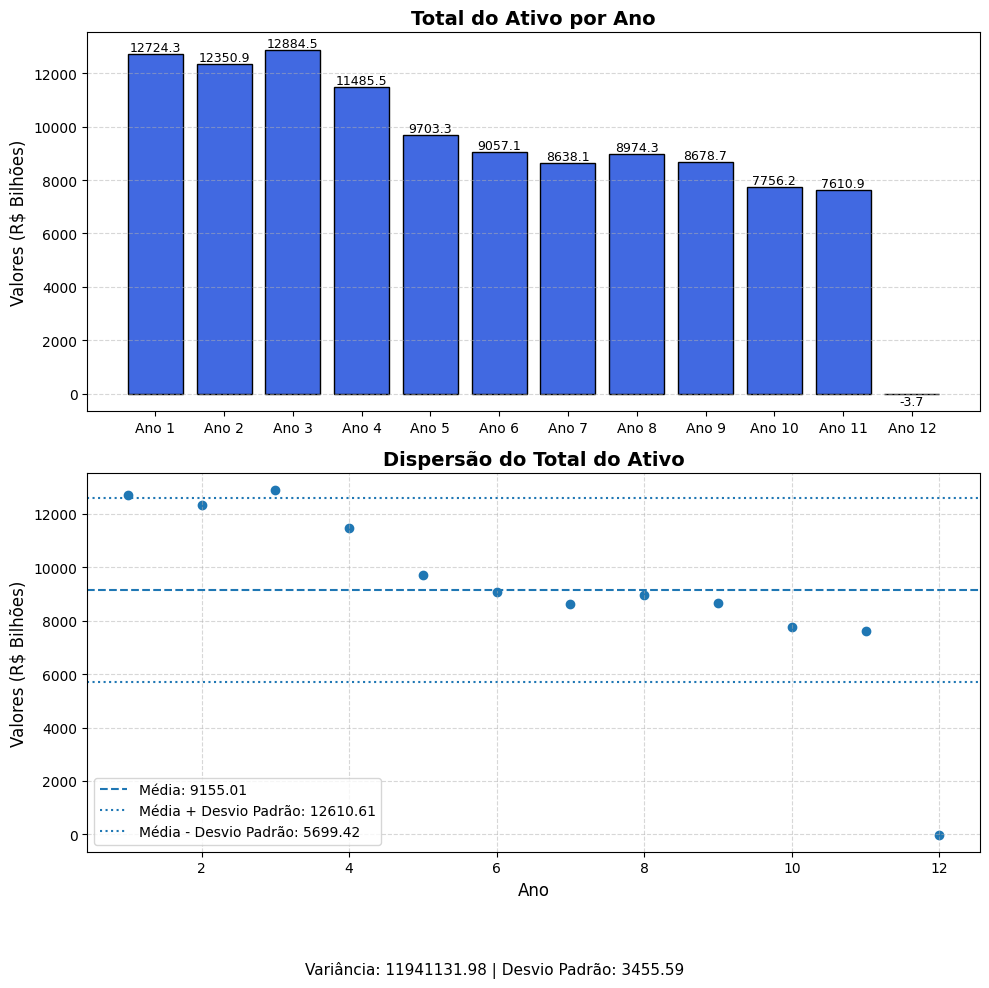

In [ ]:
import matplotlib.pyplot as plt

df["NOVOVALOR"] = df["VALOR"].str.replace(".", "", regex=False).str.replace(",", ".", regex=False).astype(float)

# Filtra o Total do Ativo
df_ativo = df[df["CONTA"].str.contains("Total do Ativo", na=False)]
df_agrupado = df_ativo.groupby("ANO")["NOVOVALOR"].sum().reset_index()

# Organizar
df_agrupado["NUM_ANO"] = df_agrupado["ANO"].str.extract(r"(\d+)").astype(int)
df_agrupado = df_agrupado.sort_values("NUM_ANO")

# Grafico
eixoX = df_agrupado['ANO']
eixoY = df_agrupado['NOVOVALOR'] / 1_000_000_000

plt.figure(figsize=(10, 10))

# Grafico Barra

plt.subplot(2, 1, 1)

plt.bar(eixoX, eixoY, color="royalblue", edgecolor="black")

# Adiciona os valores em cima das barras
for index, value in enumerate(eixoY):
    if value >= 0:
        plt.text(index, value + 0.1, f'{value:.1f}', ha='center', va='bottom', fontsize=9)
    else:
        plt.text(index, value - 50, f'{value:.1f}', ha='center', va='top', fontsize=9)

plt.ylabel("Valores (R$ Bilhões)", fontsize=12)
plt.title("Total do Ativo por Ano", fontsize=14, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.5)


# Dispersão

plt.subplot(2, 1, 2)

plt.scatter(df_agrupado["NUM_ANO"], eixoY)

# Média
media = eixoY.mean()

# Variância
variancia = eixoY.var()

# Desvio padrão
desvio_padrao = eixoY.std()

# Linha da média
plt.axhline(
    media,
    linestyle="--",
    label=f"Média: {media:.2f}"
)

# Média + Desvio Padrão
plt.axhline(
    media + desvio_padrao,
    linestyle=":",
    label=f"Média + Desvio Padrão: {media + desvio_padrao:.2f}"
)

# Média - Desvio Padrão
plt.axhline(
    media - desvio_padrao,
    linestyle=":",
    label=f"Média - Desvio Padrão: {media - desvio_padrao:.2f}"
)

plt.xlabel("Ano", fontsize=12)
plt.ylabel("Valores (R$ Bilhões)", fontsize=12)
plt.title("Dispersão do Total do Ativo", fontsize=14, fontweight="bold")
plt.grid(axis="both", linestyle="--", alpha=0.5)

plt.legend()

# Variância e Desvio Padrão
plt.figtext(
    0.5, 0.02,
    f"Variância: {variancia:.2f} | Desvio Padrão: {desvio_padrao:.2f}",
    ha="center",
    fontsize=11
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

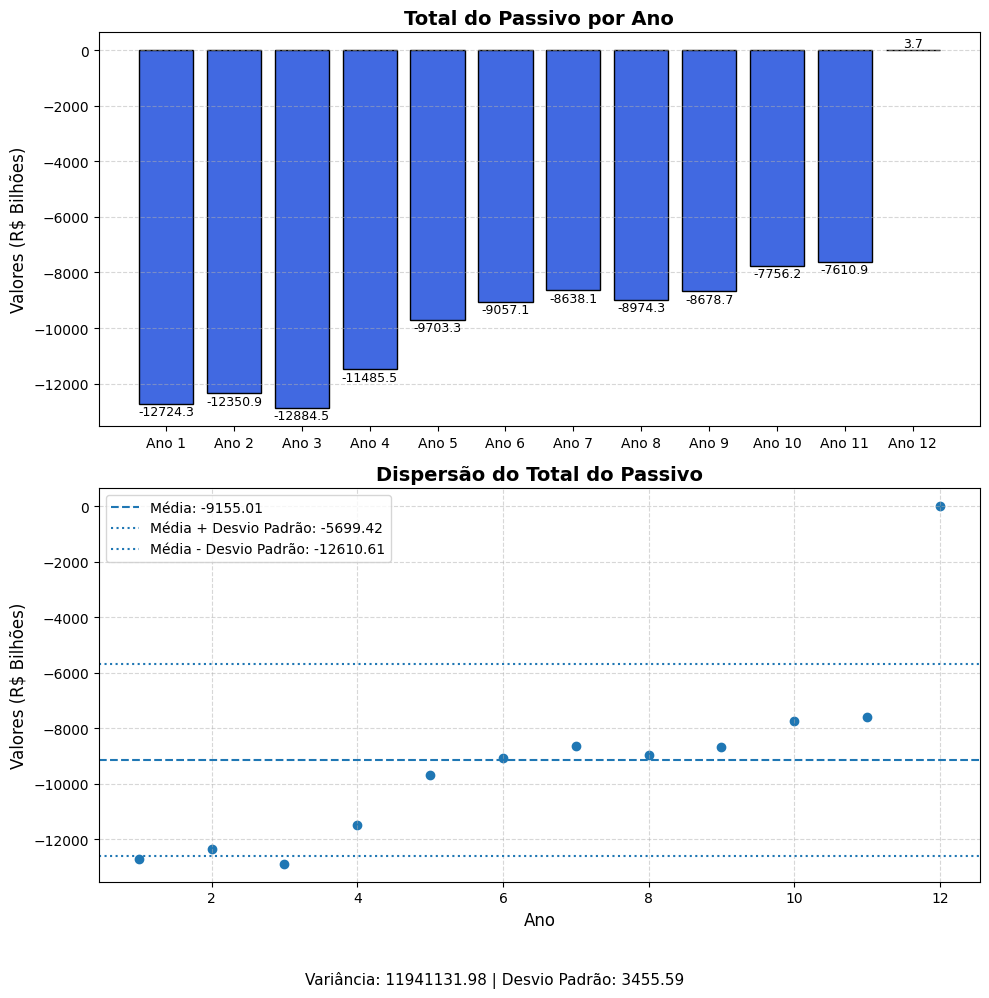

In [ ]:
import matplotlib.pyplot as plt

df["NOVOVALOR"] = df["VALOR"].str.replace(".", "", regex=False).str.replace(",", ".", regex=False).astype(float)

# Filtrar o Passivo
df_passivo = df[df["CONTA"].str.contains("Total do Passivo", na=False)]
df_agrupado = df_passivo.groupby("ANO")["NOVOVALOR"].sum().reset_index()

# Organizar
df_agrupado["NUM_ANO"] = df_agrupado["ANO"].str.extract(r"(\d+)").astype(int)
df_agrupado = df_agrupado.sort_values("NUM_ANO")

# Grafico
eixoX = df_agrupado['ANO']
eixoY = df_agrupado['NOVOVALOR'] / 1_000_000_000

plt.figure(figsize=(10, 10))

# ---------------- GRÁFICO DE BARRAS ----------------

plt.subplot(2, 1, 1)

plt.bar(eixoX, eixoY, color="royalblue", edgecolor="black")

# Adiciona os valores em cima das barras
for index, value in enumerate(eixoY):
    if value >= 0:
        plt.text(index, value + 0.1, f'{value:.1f}', ha='center', va='bottom', fontsize=9)
    else:
        plt.text(index, value - 50, f'{value:.1f}', ha='center', va='top', fontsize=9)

plt.ylabel("Valores (R$ Bilhões)", fontsize=12)
plt.title("Total do Passivo por Ano", fontsize=14, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.5)


# ---------------- GRÁFICO DE DISPERSÃO ----------------

plt.subplot(2, 1, 2)

plt.scatter(df_agrupado["NUM_ANO"], eixoY)

# Média
media = eixoY.mean()

# Variância
variancia = eixoY.var()

# Desvio padrão
desvio_padrao = eixoY.std()

# Linha da média
plt.axhline(
    media,
    linestyle="--",
    label=f"Média: {media:.2f}"
)

# Média + Desvio Padrão
plt.axhline(
    media + desvio_padrao,
    linestyle=":",
    label=f"Média + Desvio Padrão: {media + desvio_padrao:.2f}"
)

# Média - Desvio Padrão
plt.axhline(
    media - desvio_padrao,
    linestyle=":",
    label=f"Média - Desvio Padrão: {media - desvio_padrao:.2f}"
)

plt.xlabel("Ano", fontsize=12)
plt.ylabel("Valores (R$ Bilhões)", fontsize=12)
plt.title("Dispersão do Total do Passivo", fontsize=14, fontweight="bold")
plt.grid(axis="both", linestyle="--", alpha=0.5)

plt.legend()

# Mostrar variância e desvio padrão
plt.figtext(
    0.5, 0.01,
    f"Variância: {variancia:.2f} | Desvio Padrão: {desvio_padrao:.2f}",
    ha="center",
    fontsize=11
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

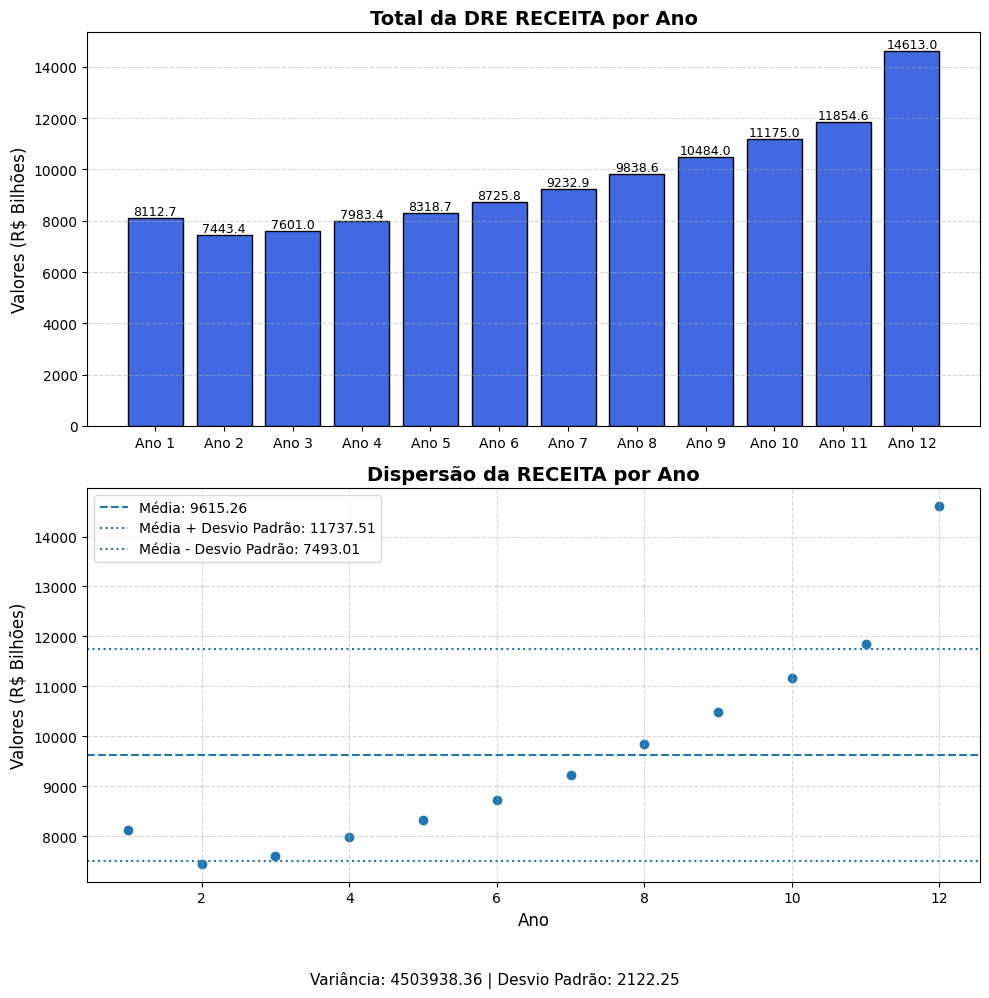

In [ ]:
import matplotlib.pyplot as plt

df["NOVOVALOR"] = df["VALOR"].str.replace(".", "", regex=False).str.replace(",", ".", regex=False).astype(float)

# Filtrar a Receita
df_receita = df[df["CONTA"].str.contains("DRE - Receita", na=False)]
df_agrupado = df_receita.groupby("ANO")["NOVOVALOR"].sum().reset_index()

# Organizar
df_agrupado["NUM_ANO"] = df_agrupado["ANO"].str.extract(r"(\d+)").astype(int)
df_agrupado = df_agrupado.sort_values("NUM_ANO")

# Grafico
eixoX = df_agrupado['ANO']
eixoY = df_agrupado['NOVOVALOR'] / 1_000_000_000

plt.figure(figsize=(10, 10))

# ---------------- GRÁFICO DE BARRAS ----------------

plt.subplot(2, 1, 1)

plt.bar(eixoX, eixoY, color="royalblue", edgecolor="black")

# Adiciona os valores em cima das barras
for index, value in enumerate(eixoY):
    if value >= 0:
        plt.text(index, value + 0.1, f'{value:.1f}', ha='center', va='bottom', fontsize=9)
    else:
        plt.text(index, value - 50, f'{value:.1f}', ha='center', va='top', fontsize=9)

plt.ylabel("Valores (R$ Bilhões)", fontsize=12)
plt.title("Total da DRE RECEITA por Ano", fontsize=14, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.5)


# ---------------- VARIÂNCIA E DESVIO PADRÃO ----------------

plt.subplot(2, 1, 2)

plt.scatter(df_agrupado["NUM_ANO"], eixoY)

# Variância
variancia = eixoY.var()

# Desvio padrão
desvio_padrao = eixoY.std()

# Média
media = eixoY.mean()

# Linhas da média + desvio padrão
plt.axhline(
    media,
    linestyle="--",
    label=f"Média: {media:.2f}"
)

plt.axhline(
    media + desvio_padrao,
    linestyle=":",
    label=f"Média + Desvio Padrão: {media + desvio_padrao:.2f}"
)

plt.axhline(
    media - desvio_padrao,
    linestyle=":",
    label=f"Média - Desvio Padrão: {media - desvio_padrao:.2f}"
)

plt.xlabel("Ano", fontsize=12)
plt.ylabel("Valores (R$ Bilhões)", fontsize=12)
plt.title("Dispersão da RECEITA por Ano", fontsize=14, fontweight="bold")
plt.grid(axis="both", linestyle="--", alpha=0.5)

plt.legend()

# Mostrar os valores da variância e desvio padrão
plt.figtext(
    0.5, 0.01,
    f"Variância: {variancia:.2f} | Desvio Padrão: {desvio_padrao:.2f}",
    ha="center",
    fontsize=11
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

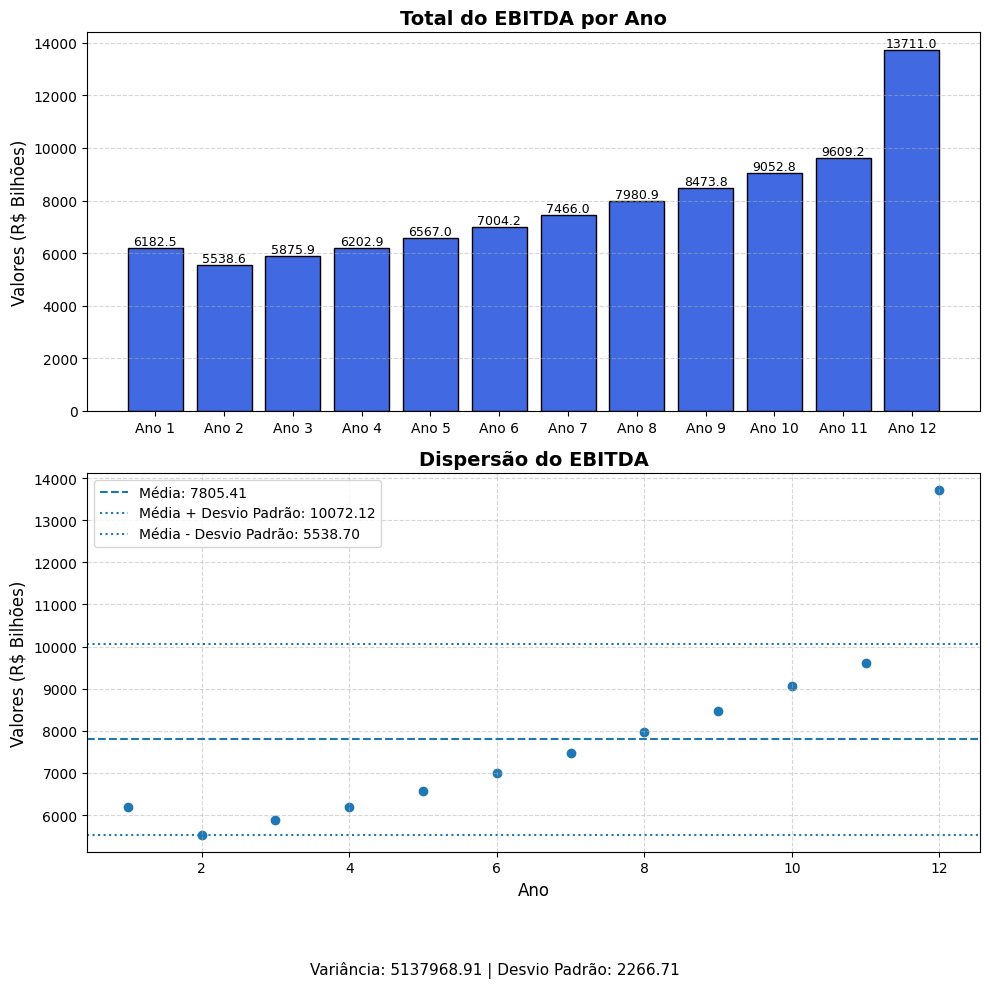

In [ ]:
import matplotlib.pyplot as plt

df["NOVOVALOR"] = df["VALOR"].str.replace(".", "", regex=False).str.replace(",", ".", regex=False).astype(float)

# Filtrar o ebitda
df_ebitda = df[df["CONTA"].str.contains("DRE - EBITDA", na=False)]
df_agrupado = df_ebitda.groupby("ANO")["NOVOVALOR"].sum().reset_index()

# Organizar
df_agrupado["NUM_ANO"] = df_agrupado["ANO"].str.extract(r"(\d+)").astype(int)
df_agrupado = df_agrupado.sort_values("NUM_ANO")

# Grafico
eixoX = df_agrupado['ANO']
eixoY = df_agrupado['NOVOVALOR'] / 1_000_000_000

plt.figure(figsize=(10, 10))

# Grafico Barra

plt.subplot(2, 1, 1)

plt.bar(eixoX, eixoY, color="royalblue", edgecolor="black")

# Adiciona os valores em cima das barras
for index, value in enumerate(eixoY):
    if value >= 0:
        plt.text(index, value + 0.1, f'{value:.1f}', ha='center', va='bottom', fontsize=9)
    else:
        plt.text(index, value - 50, f'{value:.1f}', ha='center', va='top', fontsize=9)

plt.ylabel("Valores (R$ Bilhões)", fontsize=12)
plt.title("Total do EBITDA por Ano", fontsize=14, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.5)


# Dispersão

plt.subplot(2, 1, 2)

plt.scatter(df_agrupado["NUM_ANO"], eixoY)

# Média
media = eixoY.mean()

# Variância
variancia = eixoY.var()

# Desvio padrão
desvio_padrao = eixoY.std()

# Linha da média
plt.axhline(
    media,
    linestyle="--",
    label=f"Média: {media:.2f}"
)

# Média + Desvio Padrão
plt.axhline(
    media + desvio_padrao,
    linestyle=":",
    label=f"Média + Desvio Padrão: {media + desvio_padrao:.2f}"
)

# Média - Desvio Padrão
plt.axhline(
    media - desvio_padrao,
    linestyle=":",
    label=f"Média - Desvio Padrão: {media - desvio_padrao:.2f}"
)

plt.xlabel("Ano", fontsize=12)
plt.ylabel("Valores (R$ Bilhões)", fontsize=12)
plt.title("Dispersão do EBITDA", fontsize=14, fontweight="bold")
plt.grid(axis="both", linestyle="--", alpha=0.5)

plt.legend()

# Variância e Desvio Padrão
plt.figtext(
    0.5, 0.02,
    f"Variância: {variancia:.2f} | Desvio Padrão: {desvio_padrao:.2f}",
    ha="center",
    fontsize=11
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.show()

In [ ]:
# Ainda não sei porque preciso disso para funcionar a maldita tabela
df = pd.read_csv(
    "Demonstrativo.csv",
    sep=";",
    header=None,
    names=["ANO", "CENA", "CONTA", "VALOR"]
    )

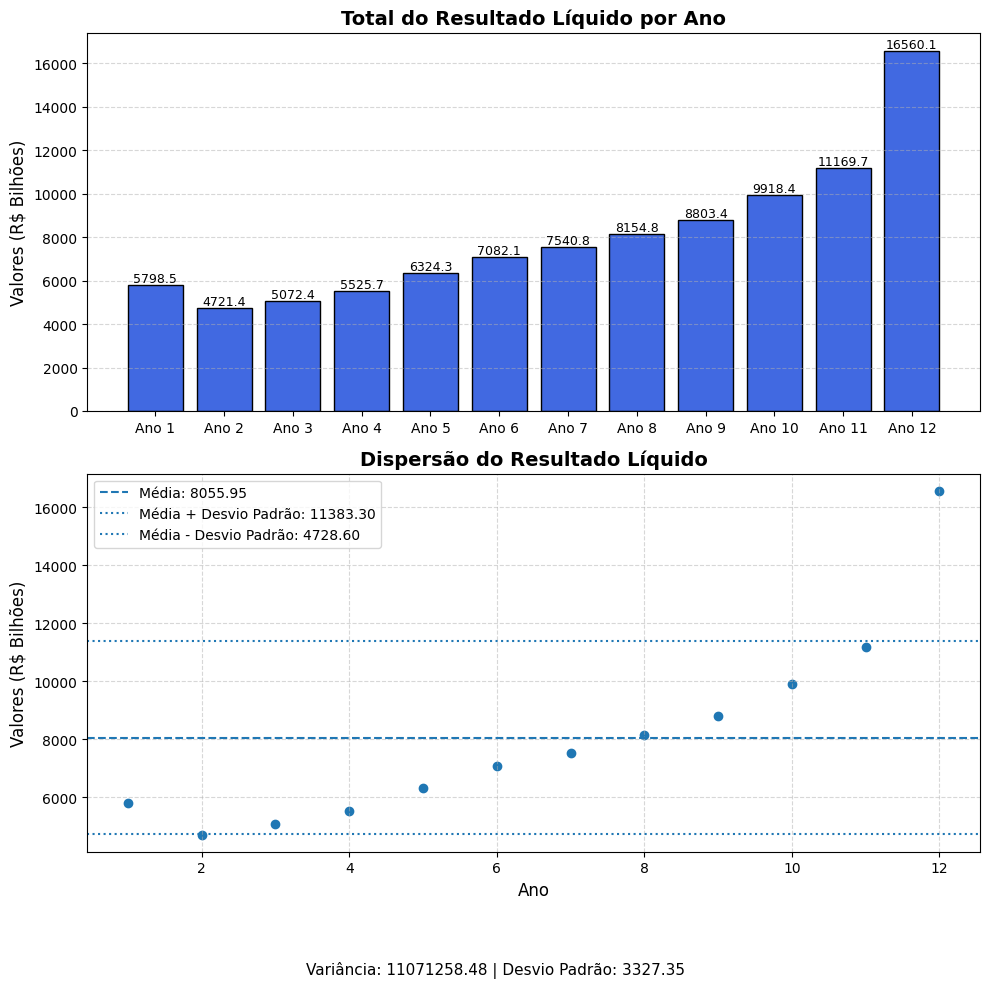

In [ ]:
import matplotlib.pyplot as plt

df["NOVOVALOR"] = df["VALOR"].str.replace(".", "", regex=False).str.replace(",", ".", regex=False).astype(float)

# Filtrar o Resultado Líquido
df_resul = df[df["CONTA"].str.contains("DRE - Resultado Líquido", na=False)]
df_agrupado = df_resul.groupby("ANO")["NOVOVALOR"].sum().reset_index()

# Organizar
df_agrupado["NUM_ANO"] = df_agrupado["ANO"].str.extract(r"(\d+)").astype(int)
df_agrupado = df_agrupado.sort_values("NUM_ANO")

# Grafico
eixoX = df_agrupado['ANO']
eixoY = df_agrupado['NOVOVALOR'] / 1_000_000_000

plt.figure(figsize=(10, 10))

# Grafico Barra

plt.subplot(2, 1, 1)

plt.bar(eixoX, eixoY, color="royalblue", edgecolor="black")

# Adiciona os valores em cima das barras
for index, value in enumerate(eixoY):
    if value >= 0:
        plt.text(index, value + 0.1, f'{value:.1f}', ha='center', va='bottom', fontsize=9)
    else:
        plt.text(index, value - 50, f'{value:.1f}', ha='center', va='top', fontsize=9)

plt.ylabel("Valores (R$ Bilhões)", fontsize=12)
plt.title("Total do Resultado Líquido por Ano", fontsize=14, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.5)


# Dispersão

plt.subplot(2, 1, 2)

plt.scatter(df_agrupado["NUM_ANO"], eixoY)

# Média
media = eixoY.mean()

# Variância
variancia = eixoY.var()

# Desvio padrão
desvio_padrao = eixoY.std()

# Linha da média
plt.axhline(
    media,
    linestyle="--",
    label=f"Média: {media:.2f}"
)

# Média + Desvio Padrão
plt.axhline(
    media + desvio_padrao,
    linestyle=":",
    label=f"Média + Desvio Padrão: {media + desvio_padrao:.2f}"
)

# Média - Desvio Padrão
plt.axhline(
    media - desvio_padrao,
    linestyle=":",
    label=f"Média - Desvio Padrão: {media - desvio_padrao:.2f}"
)

plt.xlabel("Ano", fontsize=12)
plt.ylabel("Valores (R$ Bilhões)", fontsize=12)
plt.title("Dispersão do Resultado Líquido", fontsize=14, fontweight="bold")
plt.grid(axis="both", linestyle="--", alpha=0.5)

plt.legend()

# Variância e Desvio Padrão
plt.figtext(
    0.5, 0.02,
    f"Variância: {variancia:.2f} | Desvio Padrão: {desvio_padrao:.2f}",
    ha="center",
    fontsize=11
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.show()

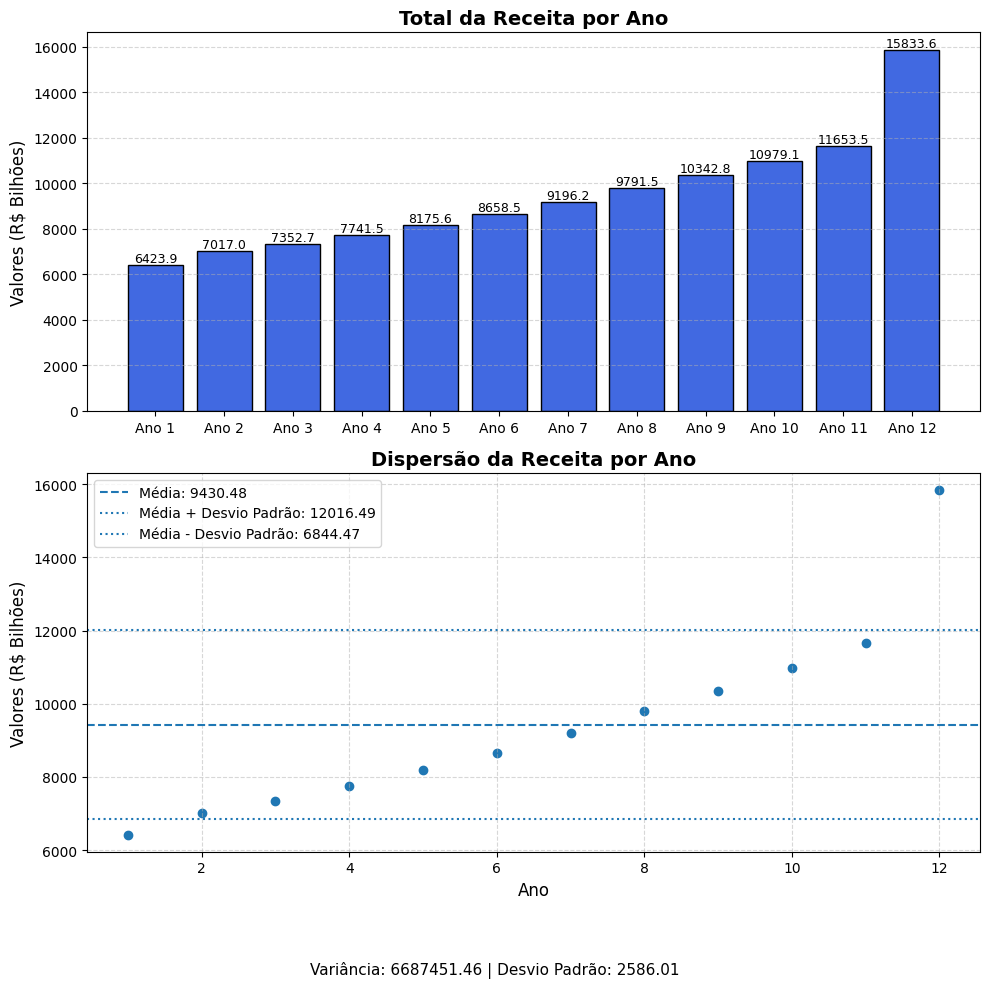

In [ ]:
import matplotlib.pyplot as plt

df["NOVOVALOR"] = df["VALOR"].str.replace(".", "", regex=False).str.replace(",", ".", regex=False).astype(float)

# Filtrar a Receita
df_receita2 = df[df["CONTA"].str.contains("FLU - Receita", na=False)]
df_agrupado = df_receita2.groupby("ANO")["NOVOVALOR"].sum().reset_index()

# Organizar
df_agrupado["NUM_ANO"] = df_agrupado["ANO"].str.extract(r"(\d+)").astype(int)
df_agrupado = df_agrupado.sort_values("NUM_ANO")

# Grafico
eixoX = df_agrupado['ANO']
eixoY = df_agrupado['NOVOVALOR'] / 1_000_000_000

plt.figure(figsize=(10, 10))

# ---------------- GRÁFICO DE BARRAS ----------------

plt.subplot(2, 1, 1)

plt.bar(eixoX, eixoY, color="royalblue", edgecolor="black")

# Adiciona os valores em cima das barras
for index, value in enumerate(eixoY):
    if value >= 0:
        plt.text(index, value + 0.1, f'{value:.1f}', ha='center', va='bottom', fontsize=9)
    else:
        plt.text(index, value - 50, f'{value:.1f}', ha='center', va='top', fontsize=9)

plt.ylabel("Valores (R$ Bilhões)", fontsize=12)
plt.title("Total da Receita por Ano", fontsize=14, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.5)


# ---------------- GRÁFICO DE DISPERSÃO ----------------

plt.subplot(2, 1, 2)

plt.scatter(df_agrupado["NUM_ANO"], eixoY)

# Média
media = eixoY.mean()

# Variância
variancia = eixoY.var()

# Desvio padrão
desvio_padrao = eixoY.std()

# Linha da média
plt.axhline(
    media,
    linestyle="--",
    label=f"Média: {media:.2f}"
)

# Média + Desvio Padrão
plt.axhline(
    media + desvio_padrao,
    linestyle=":",
    label=f"Média + Desvio Padrão: {media + desvio_padrao:.2f}"
)

# Média - Desvio Padrão
plt.axhline(
    media - desvio_padrao,
    linestyle=":",
    label=f"Média - Desvio Padrão: {media - desvio_padrao:.2f}"
)

plt.xlabel("Ano", fontsize=12)
plt.ylabel("Valores (R$ Bilhões)", fontsize=12)
plt.title("Dispersão da Receita por Ano", fontsize=14, fontweight="bold")
plt.grid(axis="both", linestyle="--", alpha=0.5)

plt.legend()

# Variância e Desvio Padrão
plt.figtext(
    0.5, 0.02,
    f"Variância: {variancia:.2f} | Desvio Padrão: {desvio_padrao:.2f}",
    ha="center",
    fontsize=11
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.show()

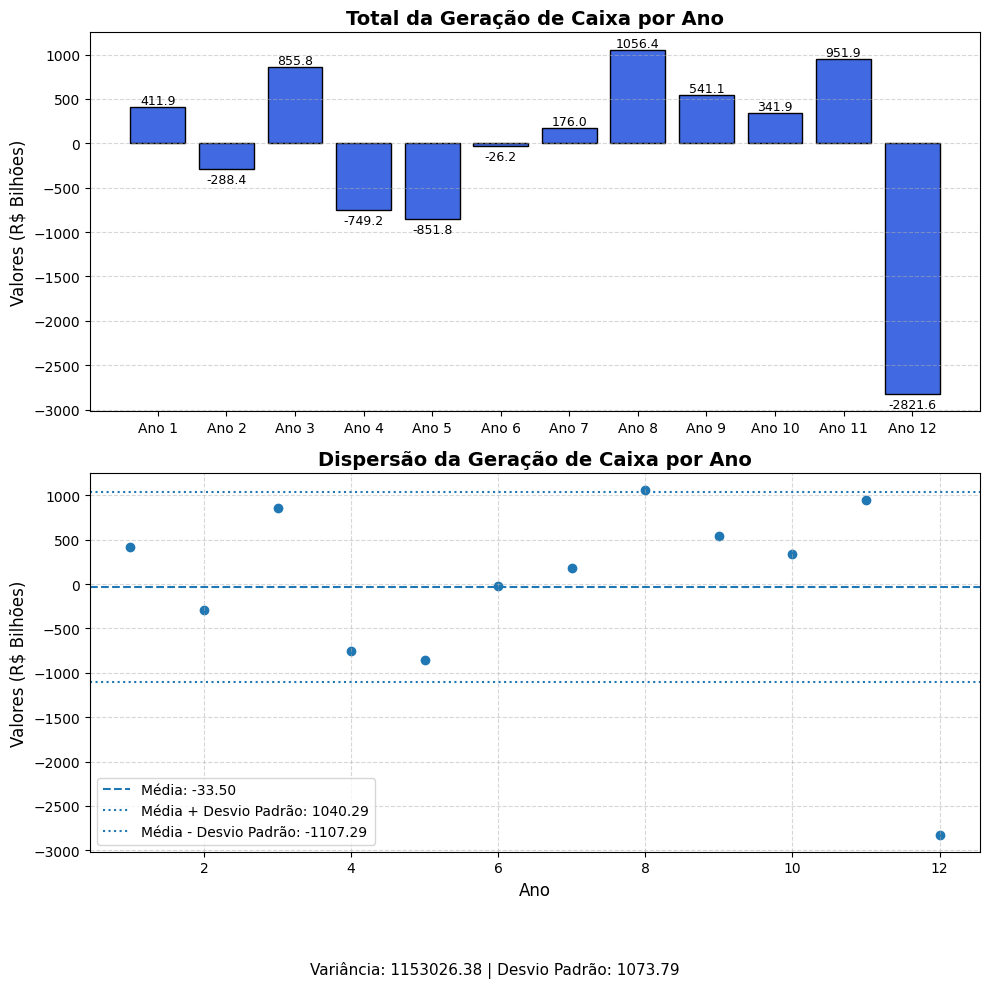

In [ ]:
import matplotlib.pyplot as plt

df["NOVOVALOR"] = df["VALOR"].str.replace(".", "", regex=False).str.replace(",", ".", regex=False).astype(float)

# Filtrar a Receita
df_caixa = df[df["CONTA"].str.contains("FLU - Geração de Caixa", na=False)]
df_agrupado = df_caixa.groupby("ANO")["NOVOVALOR"].sum().reset_index()

# Organizar
df_agrupado["NUM_ANO"] = df_agrupado["ANO"].str.extract(r"(\d+)").astype(int)
df_agrupado = df_agrupado.sort_values("NUM_ANO")

# Grafico
eixoX = df_agrupado['ANO']
eixoY = df_agrupado['NOVOVALOR'] / 1_000_000_000

plt.figure(figsize=(10, 10))

# ---------------- GRÁFICO DE BARRAS ----------------

plt.subplot(2, 1, 1)

plt.bar(eixoX, eixoY, color="royalblue", edgecolor="black")

# Adiciona os valores em cima das barras
for index, value in enumerate(eixoY):
    if value >= 0:
        plt.text(index, value + 0.1, f'{value:.1f}', ha='center', va='bottom', fontsize=9)
    else:
        plt.text(index, value - 50, f'{value:.1f}', ha='center', va='top', fontsize=9)

plt.ylabel("Valores (R$ Bilhões)", fontsize=12)
plt.title("Total da Geração de Caixa por Ano", fontsize=14, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.5)


# ---------------- GRÁFICO DE DISPERSÃO ----------------

plt.subplot(2, 1, 2)

plt.scatter(df_agrupado["NUM_ANO"], eixoY)

# Média
media = eixoY.mean()

# Variância
variancia = eixoY.var()

# Desvio padrão
desvio_padrao = eixoY.std()

# Linha da média
plt.axhline(
    media,
    linestyle="--",
    label=f"Média: {media:.2f}"
)

# Média + Desvio Padrão
plt.axhline(
    media + desvio_padrao,
    linestyle=":",
    label=f"Média + Desvio Padrão: {media + desvio_padrao:.2f}"
)

# Média - Desvio Padrão
plt.axhline(
    media - desvio_padrao,
    linestyle=":",
    label=f"Média - Desvio Padrão: {media - desvio_padrao:.2f}"
)

plt.xlabel("Ano", fontsize=12)
plt.ylabel("Valores (R$ Bilhões)", fontsize=12)
plt.title("Dispersão da Geração de Caixa por Ano", fontsize=14, fontweight="bold")
plt.grid(axis="both", linestyle="--", alpha=0.5)

plt.legend()

# Variância e Desvio Padrão
plt.figtext(
    0.5, 0.02,
    f"Variância: {variancia:.2f} | Desvio Padrão: {desvio_padrao:.2f}",
    ha="center",
    fontsize=11
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.show()

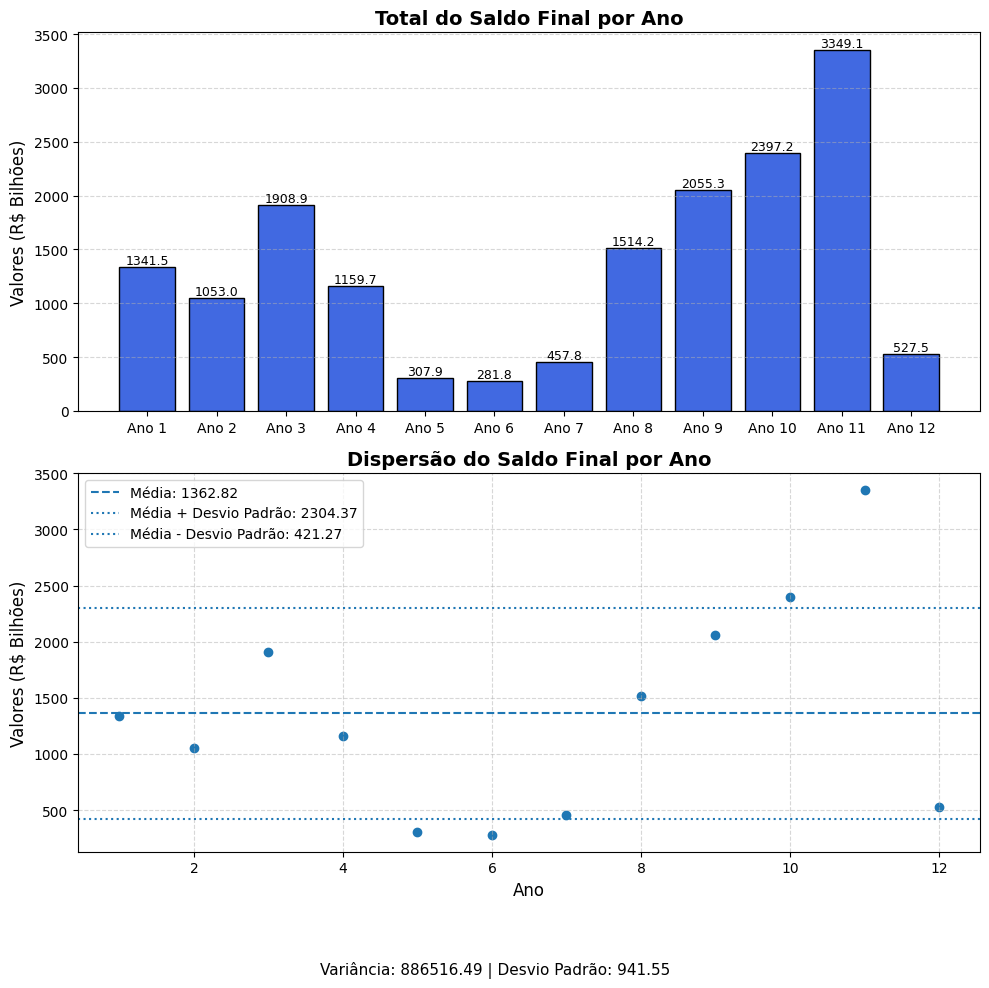

In [ ]:
import matplotlib.pyplot as plt

df["NOVOVALOR"] = df["VALOR"].str.replace(".", "", regex=False).str.replace(",", ".", regex=False).astype(float)

# Filtrar o Saldo Final
df_final = df[df["CONTA"].str.contains("FLU - Saldo Final", na=False)]
df_agrupado = df_final.groupby("ANO")["NOVOVALOR"].sum().reset_index()

# Organizar
df_agrupado["NUM_ANO"] = df_agrupado["ANO"].str.extract(r"(\d+)").astype(int)
df_agrupado = df_agrupado.sort_values("NUM_ANO")

# Dados
eixoX = df_agrupado["ANO"]
eixoY = df_agrupado["NOVOVALOR"] / 1_000_000_000

# Criar a figura
plt.figure(figsize=(10, 10))

# =========================
# Gráfico de barras
# =========================
plt.subplot(2, 1, 1)

plt.bar(eixoX, eixoY, color="royalblue", edgecolor="black")

# Adiciona os valores nas barras
for index, value in enumerate(eixoY):
    if value >= 0:
        plt.text(index, value + 0.1, f'{value:.1f}',
                 ha='center', va='bottom', fontsize=9)
    else:
        plt.text(index, value - 50, f'{value:.1f}',
                 ha='center', va='top', fontsize=9)

plt.ylabel("Valores (R$ Bilhões)", fontsize=12)
plt.title("Total do Saldo Final por Ano", fontsize=14, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.5)

# =========================
# Gráfico de dispersão
# =========================
plt.subplot(2, 1, 2)

plt.scatter(df_agrupado["NUM_ANO"], eixoY)

# Cálculos estatísticos
media = eixoY.mean()
variancia = eixoY.var()
desvio_padrao = eixoY.std()

# Linhas estatísticas
plt.axhline(media, linestyle="--",
            label=f"Média: {media:.2f}")

plt.axhline(media + desvio_padrao, linestyle=":",
            label=f"Média + Desvio Padrão: {media + desvio_padrao:.2f}")

plt.axhline(media - desvio_padrao, linestyle=":",
            label=f"Média - Desvio Padrão: {media - desvio_padrao:.2f}")

plt.xlabel("Ano", fontsize=12)
plt.ylabel("Valores (R$ Bilhões)", fontsize=12)
plt.title("Dispersão do Saldo Final por Ano", fontsize=14, fontweight="bold")

plt.grid(axis="both", linestyle="--", alpha=0.5)
plt.legend()

# Informações estatísticas
plt.figtext(
    0.5, 0.02,
    f"Variância: {variancia:.2f} | Desvio Padrão: {desvio_padrao:.2f}",
    ha="center",
    fontsize=11
)

# Espaço para o texto inferior
plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.show()

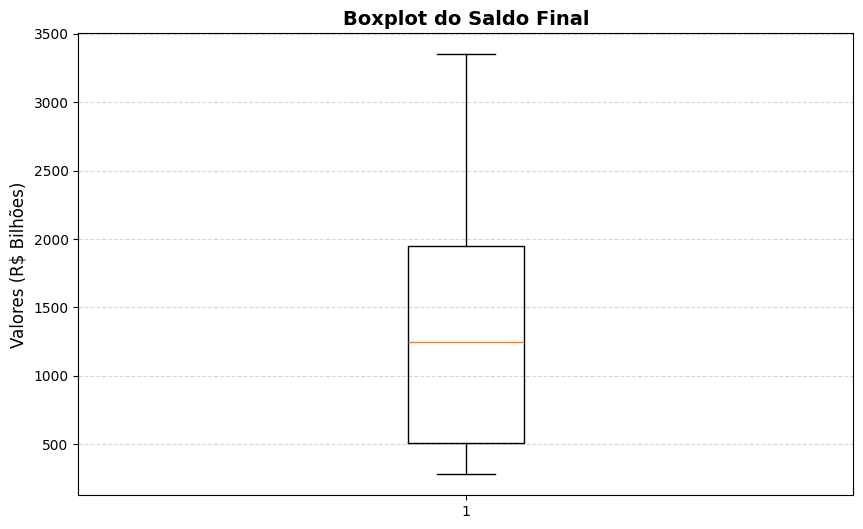

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.boxplot(eixoY)

plt.ylabel("Valores (R$ Bilhões)", fontsize=12)
plt.title("Boxplot do Saldo Final", fontsize=14, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

from ipywidgets import Dropdown, Button, VBox, HBox, Output
from IPython.display import display, clear_output


# Preparar os dados
if "NOVOVALOR" not in df.columns:
    df["NOVOVALOR"] = (
        df["VALOR"]
        .astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
    )

    df["NOVOVALOR"] = pd.to_numeric(
        df["NOVOVALOR"],
        errors="coerce"
    )


df["NUM_ANO"] = pd.to_numeric(
    df["ANO"]
    .astype(str)
    .str.extract(r"(\d+)")[0],
    errors="coerce"
)


# Identificar BAL, DRE e FLU
def identificar_demonstrativo(conta):

    if pd.isna(conta):
        return None

    conta = str(conta).strip()

    if conta.startswith("BAL"):
        return "BAL"

    elif conta.startswith("DRE"):
        return "DRE"

    elif conta.startswith("FLU"):
        return "FLU"

    return None


df["DEMONSTRATIVO"] = df["CONTA"].apply(
    identificar_demonstrativo
)


# Limpar nome das contas
df["CONTA_LIMPA"] = (
    df["CONTA"]
    .astype(str)
    .str.replace(
        r"^(BAL|DRE|FLU)\s*-\s*",
        "",
        regex=True
    )
    .str.strip()
)


# Dados utilizados pelo boxplot
dados_boxplot = df[
    df["DEMONSTRATIVO"].isin(
        ["BAL", "DRE", "FLU"]
    )
].copy()


dados_boxplot = dados_boxplot.dropna(
    subset=[
        "NOVOVALOR",
        "NUM_ANO",
        "CONTA_LIMPA"
    ]
)


# Converter para bilhões
dados_boxplot["VALOR_BILHOES"] = (
    dados_boxplot["NOVOVALOR"]
    / 1_000_000_000
)


# Formatar números
def formatar_numero(valor):

    if abs(valor) >= 1:
        return f"{valor:.2f} bi"

    elif abs(valor) >= 0.001:
        return f"{valor * 1000:.2f} mi"

    else:
        return f"{valor * 1_000_000:.2f} mil"


def formatar_bilhoes(valor):

    if pd.isna(valor):
        return "-"

    if abs(valor) >= 1:
        return f"R$ {valor:.2f} bi"

    elif abs(valor) >= 0.001:
        return f"R$ {valor * 1000:.2f} mi"

    else:
        return f"R$ {valor * 1_000_000:.2f} mil"


# Criar filtros
filtro_demonstrativo = Dropdown(
    options=[
        "BAL",
        "DRE",
        "FLU"
    ],

    value="FLU",

    description="Demonstrativo:",

    style={
        "description_width": "initial"
    },

    layout=widgets.Layout(
        width="300px"
    )
)


filtro_conta = Dropdown(
    description="Conta:",

    style={
        "description_width": "initial"
    },

    layout=widgets.Layout(
        width="600px"
    )
)


filtro_ano = Dropdown(
    options=["Todos"],

    value="Todos",

    description="Ano:",

    style={
        "description_width": "initial"
    },

    layout=widgets.Layout(
        width="250px"
    )
)


botao_gerar = Button(
    description="Gerar Boxplot",

    button_style="primary",

    icon="bar-chart",

    layout=widgets.Layout(
        width="200px",
        height="40px"
    )
)


saida = Output()


# Atualizar contas
def atualizar_contas(change=None):

    demonstrativo = filtro_demonstrativo.value

    contas = (
        dados_boxplot[
            dados_boxplot["DEMONSTRATIVO"]
            == demonstrativo
        ]["CONTA_LIMPA"]
        .dropna()
        .unique()
        .tolist()
    )

    contas = sorted(contas)

    filtro_conta.options = contas

    if len(contas) > 0:
        filtro_conta.value = contas[0]


# Atualizar anos
def atualizar_anos(change=None):

    demonstrativo = filtro_demonstrativo.value

    anos = (
        dados_boxplot[
            dados_boxplot["DEMONSTRATIVO"]
            == demonstrativo
        ]["NUM_ANO"]
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    )

    anos = sorted(anos)

    filtro_ano.options = (
        ["Todos"]
        + [f"Ano {ano}" for ano in anos]
    )

    filtro_ano.value = "Todos"


# Gerar boxplot
def gerar_boxplot(b=None):

    with saida:

        clear_output(wait=True)

        demonstrativo = filtro_demonstrativo.value
        conta = filtro_conta.value
        ano_escolhido = filtro_ano.value


        dados_filtrados = dados_boxplot[
            (
                dados_boxplot["DEMONSTRATIVO"]
                == demonstrativo
            )
            &
            (
                dados_boxplot["CONTA_LIMPA"]
                == conta
            )
        ].copy()


        if ano_escolhido != "Todos":

            numero_ano = int(
                ano_escolhido.replace(
                    "Ano ",
                    ""
                )
            )

            dados_filtrados = dados_filtrados[
                dados_filtrados["NUM_ANO"]
                == numero_ano
            ]


        if dados_filtrados.empty:

            print(
                "Nenhum dado encontrado para os filtros selecionados."
            )

            return


        fig, ax = plt.subplots(
            figsize=(15, 8)
        )


        # Todos os anos
        if ano_escolhido == "Todos":

            anos = sorted(
                dados_filtrados[
                    "NUM_ANO"
                ]
                .dropna()
                .astype(int)
                .unique()
            )


            dados_por_ano = []
            nomes_anos = []


            for ano in anos:

                valores = (
                    dados_filtrados[
                        dados_filtrados["NUM_ANO"]
                        == ano
                    ]["VALOR_BILHOES"]
                    .dropna()
                    .values
                )


                if len(valores) > 0:

                    dados_por_ano.append(
                        valores
                    )

                    nomes_anos.append(
                        f"Ano {ano}"
                    )


            box = ax.boxplot(
                dados_por_ano,

                tick_labels=nomes_anos,

                patch_artist=True,

                showmeans=True,

                showfliers=False,

                whis=(0, 100),

                medianprops={
                    "color": "black",
                    "linewidth": 2
                },

                meanprops={
                    "marker": "D",
                    "markerfacecolor": "red",
                    "markeredgecolor": "black",
                    "markersize": 6
                },

                whiskerprops={
                    "linewidth": 1.5
                },

                capprops={
                    "linewidth": 1.5
                }
            )


            for caixa in box["boxes"]:

                caixa.set_facecolor(
                    "royalblue"
                )

                caixa.set_alpha(
                    0.65
                )


            # Mostrar MÍNIMO e MÁXIMO nas pontas
            for posicao, valores in enumerate(
                dados_por_ano,
                start=1
            ):

                minimo = np.min(valores)
                maximo = np.max(valores)


                ax.annotate(
                    formatar_numero(maximo),

                    xy=(
                        posicao,
                        maximo
                    ),

                    xytext=(
                        0,
                        8
                    ),

                    textcoords="offset points",

                    ha="center",
                    va="bottom",

                    fontsize=8,
                    fontweight="bold"
                )


                ax.annotate(
                    formatar_numero(minimo),

                    xy=(
                        posicao,
                        minimo
                    ),

                    xytext=(
                        0,
                        -10
                    ),

                    textcoords="offset points",

                    ha="center",
                    va="top",

                    fontsize=8,
                    fontweight="bold"
                )


            ax.set_title(
                f"Distribuição de {conta} por Ano\n"
                f"{demonstrativo} - Todos os Cenários",

                fontsize=14,
                fontweight="bold"
            )


            ax.set_xlabel(
                "Ano",
                fontsize=12
            )


        # Ano específico
        else:

            valores = (
                dados_filtrados[
                    "VALOR_BILHOES"
                ]
                .dropna()
                .values
            )


            box = ax.boxplot(
                valores,

                tick_labels=[
                    ano_escolhido
                ],

                patch_artist=True,

                showmeans=True,

                showfliers=False,

                whis=(0, 100),

                widths=0.35,

                medianprops={
                    "color": "black",
                    "linewidth": 2
                },

                meanprops={
                    "marker": "D",
                    "markerfacecolor": "red",
                    "markeredgecolor": "black",
                    "markersize": 7
                },

                whiskerprops={
                    "linewidth": 1.5
                },

                capprops={
                    "linewidth": 1.5
                }
            )


            for caixa in box["boxes"]:

                caixa.set_facecolor(
                    "royalblue"
                )

                caixa.set_alpha(
                    0.65
                )


            minimo = np.min(valores)
            maximo = np.max(valores)


            # Valor máximo
            ax.annotate(
                formatar_numero(maximo),

                xy=(
                    1,
                    maximo
                ),

                xytext=(
                    0,
                    10
                ),

                textcoords="offset points",

                ha="center",
                va="bottom",

                fontsize=11,
                fontweight="bold"
            )


            # Valor mínimo
            ax.annotate(
                formatar_numero(minimo),

                xy=(
                    1,
                    minimo
                ),

                xytext=(
                    0,
                    -12
                ),

                textcoords="offset points",

                ha="center",
                va="top",

                fontsize=11,
                fontweight="bold"
            )


            ax.set_title(
                f"Distribuição de {conta}\n"
                f"{demonstrativo} - {ano_escolhido}",

                fontsize=14,
                fontweight="bold"
            )


            ax.set_xlabel(
                "Período",
                fontsize=12
            )


        ax.set_ylabel(
            "Valores (R$ Bilhões)",
            fontsize=12
        )


        ax.grid(
            axis="y",
            linestyle="--",
            alpha=0.4
        )


        ax.tick_params(
            axis="x",
            rotation=30
        )


        # Legenda
        ax.plot(
            [],
            [],
            marker="D",
            linestyle="None",
            markerfacecolor="red",
            markeredgecolor="black",
            label="Média"
        )


        ax.legend()


        # Criar espaço para os números das pontas
        valores_total = (
            dados_filtrados[
                "VALOR_BILHOES"
            ]
            .dropna()
        )


        minimo_total = valores_total.min()
        maximo_total = valores_total.max()

        intervalo = maximo_total - minimo_total


        if intervalo == 0:
            intervalo = abs(maximo_total) * 0.1

        if intervalo == 0:
            intervalo = 1


        ax.set_ylim(
            minimo_total - intervalo * 0.12,
            maximo_total + intervalo * 0.12
        )


        plt.tight_layout()

        plt.show()


        # Criar tabela com os números
        resumo = []


        if ano_escolhido == "Todos":

            for ano in anos:

                valores = (
                    dados_filtrados[
                        dados_filtrados["NUM_ANO"]
                        == ano
                    ]["VALOR_BILHOES"]
                    .dropna()
                )


                if len(valores) == 0:
                    continue


                resumo.append({

                    "Ano":
                        f"Ano {ano}",

                    "Mínimo":
                        valores.min(),

                    "Q1":
                        valores.quantile(0.25),

                    "Mediana":
                        valores.median(),

                    "Média":
                        valores.mean(),

                    "Q3":
                        valores.quantile(0.75),

                    "Máximo":
                        valores.max(),

                    "Desvio Padrão":
                        valores.std(),

                    "Observações":
                        len(valores)

                })


        else:

            valores = (
                dados_filtrados[
                    "VALOR_BILHOES"
                ]
                .dropna()
            )


            resumo.append({

                "Ano":
                    ano_escolhido,

                "Mínimo":
                    valores.min(),

                "Q1":
                    valores.quantile(0.25),

                "Mediana":
                    valores.median(),

                "Média":
                    valores.mean(),

                "Q3":
                    valores.quantile(0.75),

                "Máximo":
                    valores.max(),

                "Desvio Padrão":
                    valores.std(),

                "Observações":
                    len(valores)

            })


        tabela_resumo = pd.DataFrame(
            resumo
        )


        colunas_valores = [
            "Mínimo",
            "Q1",
            "Mediana",
            "Média",
            "Q3",
            "Máximo",
            "Desvio Padrão"
        ]


        tabela_formatada = tabela_resumo.copy()


        for coluna in colunas_valores:

            tabela_formatada[coluna] = (
                tabela_formatada[coluna]
                .apply(formatar_bilhoes)
            )


        print()
        print("RESUMO ESTATÍSTICO")
        print()


        display(
            tabela_formatada.style
            .set_properties(
                **{
                    "text-align": "center"
                }
            )
            .set_table_styles([
                {
                    "selector": "th",
                    "props": [
                        ("text-align", "center"),
                        ("font-weight", "bold")
                    ]
                }
            ])
        )


# Atualizar filtros
def mudou_demonstrativo(change):

    if change["name"] == "value":

        atualizar_contas()

        atualizar_anos()


filtro_demonstrativo.observe(
    mudou_demonstrativo,
    names="value"
)


botao_gerar.on_click(
    gerar_boxplot
)


# Inicializar
atualizar_contas()
atualizar_anos()


# Interface
titulo = widgets.HTML(
    value="""
    <h2>📦 Boxplot Financeiro Interativo</h2>

    <p>
    Escolha o demonstrativo, a conta e o ano para
    analisar a distribuição dos valores entre os cenários.
    </p>

    <p>
    <b>O gráfico apresenta:</b>
    Mínimo • Q1 • Mediana • Média • Q3 • Máximo
    </p>
    """
)


interface = VBox([

    titulo,

    HBox([
        filtro_demonstrativo,
        filtro_ano
    ]),

    filtro_conta,

    botao_gerar,

    saida

])


display(interface)